# Research Question 4: Category Concentration by Quartier in 2025
<div style="background-color:#f0f4f8; padding:15px; border-left:6px solid #2f5597; border-radius:6px;">

## Research Question

Are certain types of ZüriWieNeu reports concentrated in particular Zurich Quartiere in 2025, and within the dominant category, where exactly in the city do these reports cluster?

## Goal of this notebook

The goal of this notebook is to analyse whether specific categories of ZüriWieNeu reports are spatially concentrated in certain Zurich Quartiere in 2025. The analysis proceeds in two stages. The first stage aggregates reports by Quartier and category to identify the dominant report type and the Quartiere where it is most concentrated. The second stage zooms in on this dominant category and uses a **Kernel Density Estimation (KDE)** on its point locations to show where within the city these reports actually cluster, independently of administrative boundaries.

While Research Question 3 examined the total number of reports per Quartier, this notebook focuses on the types of reports. This makes it possible to investigate whether some neighbourhoods are especially associated with certain kinds of urban issues, such as waste, street infrastructure, lighting, green spaces, or traffic signals.

## Why this question is relevant

Different Quartiere may have different urban functions and land-use patterns. For example, central or nightlife-oriented areas may show different reporting patterns than residential or peripheral areas. Analysing report categories at the Quartier level can therefore provide a more detailed understanding of urban reporting patterns in Zurich.

A Quartier-level choropleth, however, depends strongly on administrative boundaries: a large Quartier may appear less intense even if its reports cluster heavily in one corner of it. By complementing the choropleth with a Kernel Density Estimation on the points of the dominant category, this notebook can show both the administrative pattern and the underlying spatial concentration of the reports themselves.

However, category concentrations should be interpreted carefully. A high number of reports in a category may reflect actual local issues, but it may also be influenced by population density, visitor activity, infrastructure density, or differences in reporting behaviour.

## Planned analysis

In this notebook, I will:

1. Load and clean the ZüriWieNeu report data.
2. Filter the reports to the year 2025.
3. Convert report coordinates into a GeoDataFrame.
4. Spatially join reports to Zurich Quartiere.
5. Count reports by Quartier and category and compute category shares.
6. Identify the dominant report category in each Quartier.
7. Visualize the share of the dominant category on a Quartier choropleth map.
8. Run a Kernel Density Estimation on the point locations of the dominant category to reveal where within the city these reports cluster.
9. Interpret both the Quartier-level and the point-level spatial patterns.
</div>

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from src.loading import load_csv_data
from src.cleaning import clean_reports
from src.spatial import reports_to_geodataframe, join_reports_to_quartiere

In [2]:
df_raw = load_csv_data("../data/raw/stzh.zwn_meldungen_p.csv")
df_clean = clean_reports(df_raw)

df_2025 = df_clean[df_clean["year"] == 2025].copy()

quartiere = gpd.read_file(
    "../data/raw/StatQuartiere_ZH"
)

reports_2025_gdf = reports_to_geodataframe(df_2025)

reports_2025_joined = join_reports_to_quartiere(
    reports_2025_gdf,
    quartiere
)

reports_2025_joined[["service_request_id", "qname", "service_name"]].head()

/Users/laumagoldmann/Desktop/SDS210_IndividualProject/src/cleaning.py:110: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")
/Users/laumagoldmann/miniconda3/envs/sds-env/lib/python3.14/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'StatQuartiere_ZH': 'stzh.adm_statistische_quartiere_v' (default), 'stzh.adm_statistische_quartiere_b_p', 'stzh.adm_statistische_quartiere_map'. Specify layer parameter to avoid this warning.
  result = read_func(


,service_request_id,qname,service_name
44670,70201,Langstrasse,Abfall/Sammelstelle
45845,68672,Hard,Abfall/Sammelstelle
45867,69139,City,Beleuchtung/Uhren
45975,70728,Sihlfeld,Abfall/Sammelstelle
46705,65900,Hochschulen,Graffiti


In [3]:
quartier_category_counts = (
    reports_2025_joined
    .groupby(["qname", "service_name"])
    .size()
    .reset_index(name="report_count")
    .sort_values("report_count", ascending=False)
)

quartier_category_counts.head(10)

,qname,service_name,report_count
157,Langstrasse,Abfall/Sammelstelle,824
265,Sihlfeld,Abfall/Sammelstelle,477
99,Hard,Abfall/Sammelstelle,274
20,Alt-Wiedikon,Abfall/Sammelstelle,259
30,Altstetten,Abfall/Sammelstelle,244
245,Seebach,Abfall/Sammelstelle,220
275,Unterstrass,Abfall/Sammelstelle,191
294,Werd,Abfall/Sammelstelle,178
303,Wipkingen,Abfall/Sammelstelle,159
0,Affoltern,Abfall/Sammelstelle,129


In [4]:
quartier_totals = (
    reports_2025_joined
    .groupby("qname")
    .size()
    .reset_index(name="total_reports")
)

quartier_category_shares = quartier_category_counts.merge(
    quartier_totals,
    on="qname",
    how="left"
)

quartier_category_shares["category_share"] = (
    quartier_category_shares["report_count"]
    / quartier_category_shares["total_reports"]
    * 100
)

quartier_category_shares.sort_values(
    "category_share",
    ascending=False
).head(10)

,qname,service_name,report_count,total_reports,category_share
0,Langstrasse,Abfall/Sammelstelle,824,1200,68.666667
7,Werd,Abfall/Sammelstelle,178,267,66.666667
1,Sihlfeld,Abfall/Sammelstelle,477,795,60.000000
2,Hard,Abfall/Sammelstelle,274,470,58.297872
3,Alt-Wiedikon,Abfall/Sammelstelle,259,456,56.798246
15,Seefeld,Abfall/Sammelstelle,119,221,53.846154
34,Weinegg,Abfall/Sammelstelle,62,123,50.406504
5,Seebach,Abfall/Sammelstelle,220,464,47.413793
32,Mühlebach,Abfall/Sammelstelle,66,160,41.250000
9,Affoltern,Abfall/Sammelstelle,129,331,38.972810


## Category shares within Quartiere

The table above shows the categories with the highest local shares within each Quartier in 2025.

The results show that **Abfall/Sammelstelle** dominates many of the strongest Quartier-category combinations. In Langstrasse, for example, this category accounts for almost 69% of all reports. Similar patterns are visible in Werd, Sihlfeld, Hard, and Alt-Wiedikon.

This suggests that waste and collection-point issues are not only frequent across the city overall, but are especially concentrated in certain Quartiere. However, these results should be interpreted as reporting patterns rather than direct measurements of urban cleanliness or infrastructure quality.
``

In [5]:
dominant_category_by_quartier = (
    quartier_category_shares
    .sort_values(["qname", "category_share"], ascending=[True, False])
    .groupby("qname")
    .first()
    .reset_index()
)

dominant_category_by_quartier.head(10)

,qname,service_name,report_count,total_reports,category_share
0,Affoltern,Abfall/Sammelstelle,129,331,38.972810
1,Albisrieden,Abfall/Sammelstelle,122,360,33.888889
2,Alt-Wiedikon,Abfall/Sammelstelle,259,456,56.798246
3,Altstetten,Abfall/Sammelstelle,244,628,38.853503
4,City,Abfall/Sammelstelle,75,288,26.041667
5,Enge,Abfall/Sammelstelle,97,360,26.944444
6,Escher Wyss,Abfall/Sammelstelle,40,212,18.867925
7,Fluntern,Abfall/Sammelstelle,62,218,28.440367
8,Friesenberg,Abfall/Sammelstelle,54,198,27.272727
9,Gewerbeschule,Abfall/Sammelstelle,123,353,34.844193


In [6]:
dominant_category_by_quartier["service_name"].value_counts()

service_name
Abfall/Sammelstelle          32
Signalisation/Lichtsignal     2
Name: count, dtype: int64

In [7]:
abfall_share = quartier_category_shares[
    quartier_category_shares["service_name"] == "Abfall/Sammelstelle"
].copy()

abfall_share = abfall_share.sort_values(
    "category_share",
    ascending=False
)

abfall_share.head(10)

,qname,service_name,report_count,total_reports,category_share
0,Langstrasse,Abfall/Sammelstelle,824,1200,68.666667
7,Werd,Abfall/Sammelstelle,178,267,66.666667
1,Sihlfeld,Abfall/Sammelstelle,477,795,60.000000
2,Hard,Abfall/Sammelstelle,274,470,58.297872
3,Alt-Wiedikon,Abfall/Sammelstelle,259,456,56.798246
15,Seefeld,Abfall/Sammelstelle,119,221,53.846154
34,Weinegg,Abfall/Sammelstelle,62,123,50.406504
5,Seebach,Abfall/Sammelstelle,220,464,47.413793
32,Mühlebach,Abfall/Sammelstelle,66,160,41.250000
9,Affoltern,Abfall/Sammelstelle,129,331,38.972810


In [8]:
quartiere_abfall_share = quartiere.merge(
    abfall_share[["qname", "category_share", "report_count", "total_reports"]],
    on="qname",
    how="left"
)

quartiere_abfall_share[["qname", "category_share", "report_count", "total_reports"]].sort_values(
    "category_share",
    ascending=False
).head(10)

,qname,category_share,report_count,total_reports
2,Langstrasse,68.666667,824,1200
27,Werd,66.666667,178,267
17,Sihlfeld,60.000000,477,795
29,Hard,58.297872,274,470
0,Alt-Wiedikon,56.798246,259,456
6,Seefeld,53.846154,119,221
5,Weinegg,50.406504,62,123
32,Seebach,47.413793,220,464
9,Mühlebach,41.250000,66,160
18,Affoltern,38.972810,129,331


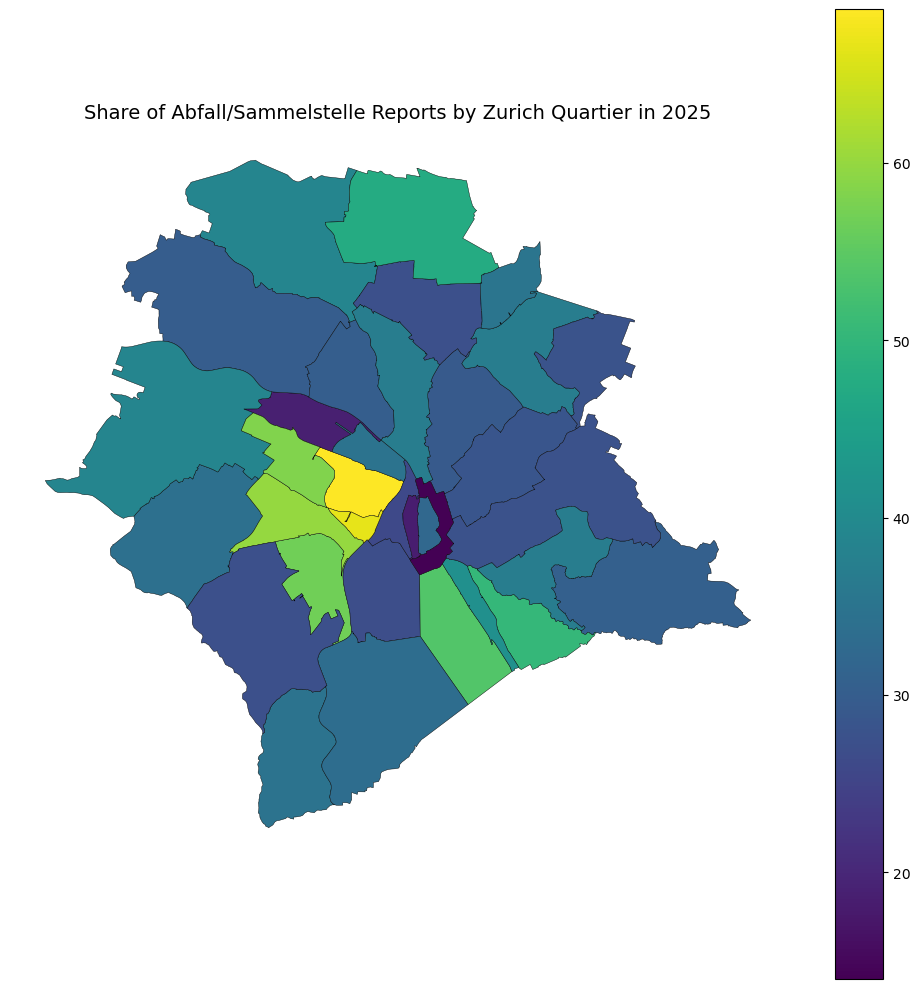

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

quartiere_abfall_share.plot(
    column="category_share",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

ax.set_title(
    "Share of Abfall/Sammelstelle Reports by Zurich Quartier in 2025",
    fontsize=14
)

ax.axis("off")

plt.tight_layout()
plt.savefig("../outputs/R4_Share_LargestReport_ByQuartier.png", bbox_inches="tight")
plt.show()

<div style="background-color:#eef6ff; padding:15px; border-left:6px solid #4a90e2; border-radius:6px;">

## Interpretation of the Abfall/Sammelstelle share map

The choropleth map shows the share of **Abfall/Sammelstelle** reports within each Zurich Quartier in 2025.

This relative measure is useful because it does not only show where many waste-related reports occurred, but where waste-related reports made up a particularly large proportion of all local reports.

The map shows that **Abfall/Sammelstelle** reports are especially concentrated in Quartiere such as **Langstrasse**, **Werd**, **Sihlfeld**, **Hard**, and **Alt-Wiedikon**. In Langstrasse, for example, almost 69% of all ZüriWieNeu reports in 2025 belonged to this category.

This suggests that waste and collection-point issues were particularly important in these Quartiere compared with other types of reported problems. However, the results should be interpreted as reporting patterns rather than direct measurements of cleanliness or infrastructure quality. High shares may also be influenced by population density, nightlife, visitor activity, commercial land use, or differences in residents' reporting behaviour.

<div style="background-color:#eef9f0; padding:15px; border-left:6px solid #3c9d5d; border-radius:6px;">

## Summary so far: category concentration at the Quartier level

The first part of this notebook analysed whether certain types of ZüriWieNeu reports were concentrated in particular Zurich Quartiere in 2025.

The first analysis of Quartier-category combinations showed that **Abfall/Sammelstelle** dominated the strongest absolute concentrations. The largest combination was **Langstrasse – Abfall/Sammelstelle**, with 824 reports.

The analysis of dominant categories showed that **Abfall/Sammelstelle** was the most common category in 32 out of 34 Quartiere. This indicates that waste and collection-point issues were not only frequent citywide, but also locally dominant in most neighbourhoods.

To better understand spatial concentration, the analysis then focused on the share of **Abfall/Sammelstelle** reports within each Quartier. This revealed that the category was especially concentrated in Quartiere such as **Langstrasse**, **Werd**, **Sihlfeld**, **Hard**, and **Alt-Wiedikon**.

Overall, the Quartier-level results show that category patterns in 2025 were strongly shaped by waste-related reports. The next part of the notebook examines where within the city these **Abfall/Sammelstelle** reports actually cluster, by applying a Kernel Density Estimation directly to their point locations.

## Zooming in: Kernel Density Estimation on Abfall/Sammelstelle reports

The choropleth above shows the **share** of Abfall/Sammelstelle reports within each Quartier, but it cannot show where inside those Quartiere the reports occur. A Quartier of 1 km² with reports concentrated on a single street looks the same on a choropleth as a Quartier with reports spread evenly across its whole area.

To reveal this internal structure, the following analysis applies a Kernel Density Estimation (KDE) directly to the point locations of all Abfall/Sammelstelle reports in 2025. A KDE places a small Gaussian "bump" on top of every report and sums these bumps across the city. The result is a smooth continuous density surface, measured in reports per square metre, that is independent of Quartier boundaries.

The KDE is computed with `seaborn.kdeplot` on the LV95 coordinates of the report points. Because LV95 is a projected coordinate system in metres, the smoothing bandwidth and any distances on the map are interpretable as real-world distances rather than as degrees of longitude and latitude.

The most important parameter is `bw_adjust`, which scales the automatically chosen bandwidth (Scott's rule). Smaller values produce sharper, more localised hotspots; larger values produce a smoother surface. A value of `0.5` is used here as a balance between resolving local clusters and showing the overall city-wide pattern. The sensitivity of this choice is checked further below.

In [10]:
import seaborn as sns

abfall_points = reports_2025_joined[
    reports_2025_joined["service_name"] == "Abfall/Sammelstelle"
].copy()

print(f"Abfall/Sammelstelle reports in 2025: {len(abfall_points):,}")

Abfall/Sammelstelle reports in 2025: 4,780


For the KDE visualisation, only the outer city outline is needed as a spatial reference frame. This is obtained by dissolving the Quartier polygons into a single geometry. The Quartier boundaries are also kept as a light overlay so the density surface can be related back to the administrative analysis above.

In [11]:
city_outline = quartiere.dissolve()
city_outline.head()

,geometry,objid,objectid,qname,qnr,kname,knr
0,"POLYGON ((2680282.123 1242917.792, 2680290.76 ...",1,1,Alt-Wiedikon,31,Kreis 3,3


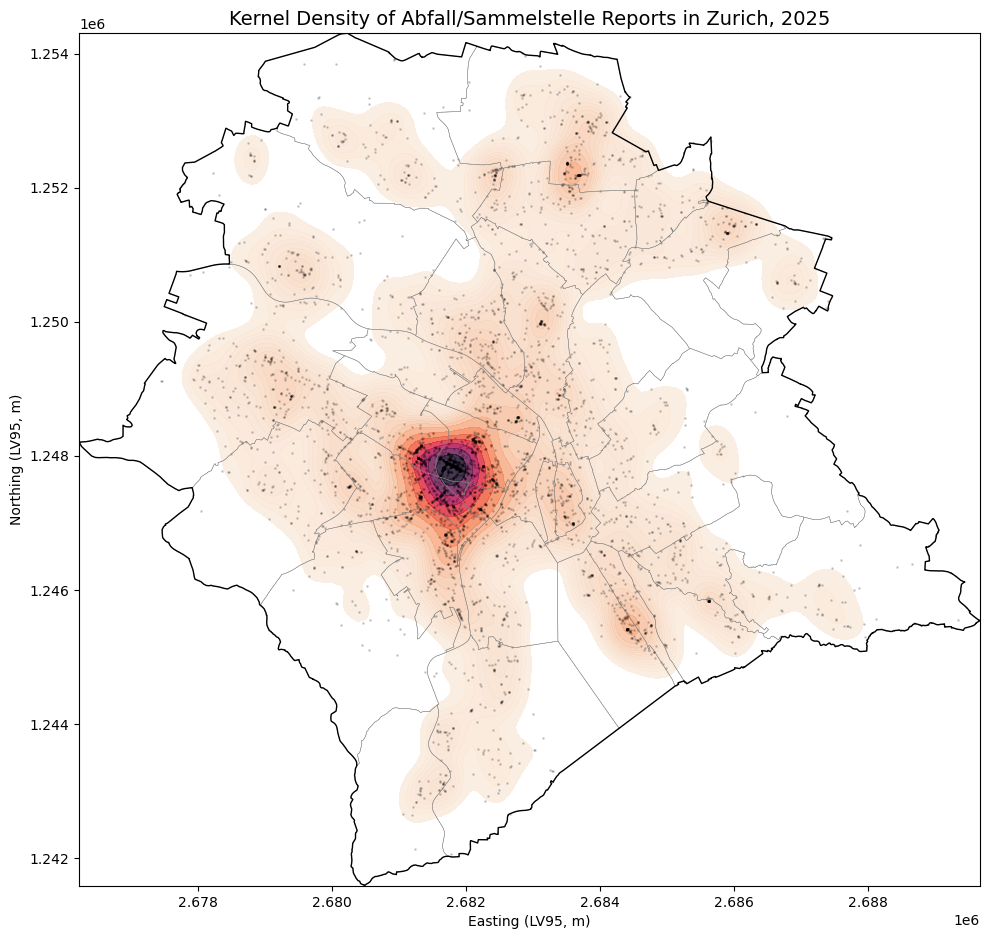

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))

sns.kdeplot(
    data=abfall_points,
    x=abfall_points.geometry.x,
    y=abfall_points.geometry.y,
    fill=True,
    cmap="rocket_r",
    levels=20,
    thresh=0.05,
    bw_adjust=0.5,
    alpha=0.85,
    ax=ax,
)

# Quartier boundaries as a light reference layer
quartiere.boundary.plot(
    ax=ax,
    color="grey",
    linewidth=0.3
)

# City outline emphasised
city_outline.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.0
)

# Individual report points, very faint
ax.scatter(
    abfall_points.geometry.x,
    abfall_points.geometry.y,
    s=1,
    color="black",
    alpha=0.15
)

ax.set_title(
    "Kernel Density of Abfall/Sammelstelle Reports in Zurich, 2025",
    fontsize=14
)
ax.set_xlabel("Easting (LV95, m)")
ax.set_ylabel("Northing (LV95, m)")
ax.set_aspect("equal")

minx, miny, maxx, maxy = city_outline.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

plt.tight_layout()
plt.savefig(
    "../outputs/R4_KDE_Abfall_2025.png",
    bbox_inches="tight",
    dpi=200
)
plt.show()

## Sensitivity of the KDE to the bandwidth

The bandwidth is the single most important choice in a KDE. To make its effect visible, the same KDE is computed for three values of `bw_adjust`: a sharper setting (`0.3`), the value used in the main map (`0.5`), and a smoother setting (`1.0`). The smaller value emphasises individual hotspots, while the larger one shows the overall pattern across the city.

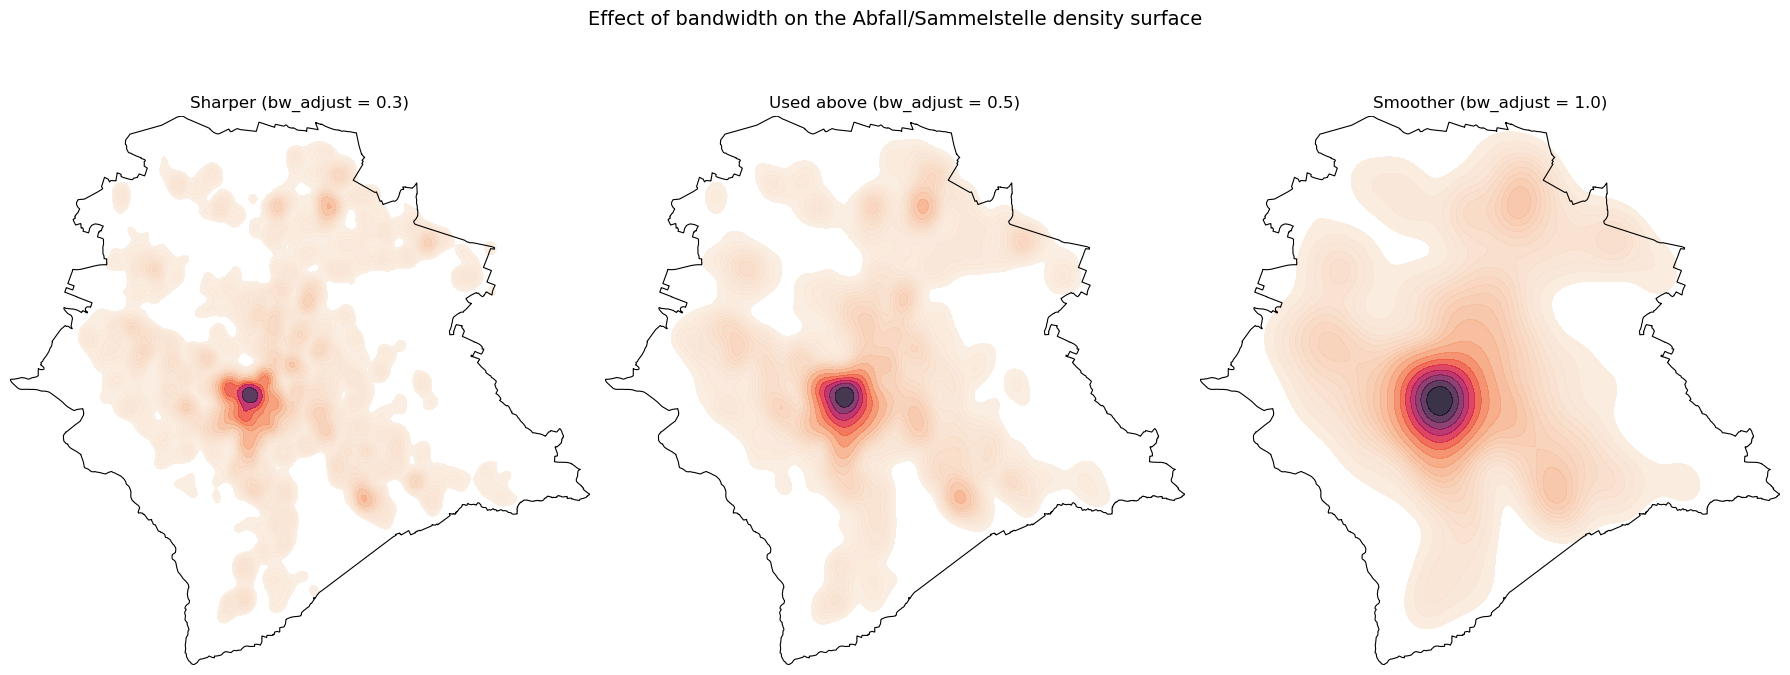

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)

bw_values = [0.3, 0.5, 1.0]
labels = [
    "Sharper (bw_adjust = 0.3)",
    "Used above (bw_adjust = 0.5)",
    "Smoother (bw_adjust = 1.0)",
]

for ax_, bw, label in zip(axes, bw_values, labels):
    sns.kdeplot(
        data=abfall_points,
        x=abfall_points.geometry.x,
        y=abfall_points.geometry.y,
        fill=True,
        cmap="rocket_r",
        levels=20,
        thresh=0.05,
        bw_adjust=bw,
        alpha=0.85,
        ax=ax_,
    )
    city_outline.boundary.plot(ax=ax_, color="black", linewidth=0.8)
    ax_.set_title(label, fontsize=12)
    ax_.set_xlim(minx, maxx)
    ax_.set_ylim(miny, maxy)
    ax_.set_aspect("equal")
    ax_.axis("off")

plt.suptitle(
    "Effect of bandwidth on the Abfall/Sammelstelle density surface",
    fontsize=14,
    y=1.02
)
plt.tight_layout()
plt.savefig(
    "../outputs/R4_KDE_Abfall_Bandwidth.png",
    bbox_inches="tight",
    dpi=200
)
plt.show()

<div style="background-color:#eef6ff; padding:15px; border-left:6px solid #4a90e2; border-radius:6px;">

## Interpretation of the Abfall/Sammelstelle density surface

The KDE heatmap shows the estimated spatial density of Abfall/Sammelstelle reports in Zurich in 2025. Compared with the choropleth above, the density surface adds two pieces of information.

First, it shows that the high Abfall/Sammelstelle share in the central Quartiere is supported by a strong **point-level concentration**, not just by a small total denominator. The Quartiere with the highest shares — **Langstrasse**, **Werd**, **Sihlfeld**, **Hard**, and **Alt-Wiedikon** — also contain the densest clusters of waste-related report points, mostly along a continuous corridor in central Zurich.

Second, the density surface shows that this concentration **does not respect Quartier boundaries**. The strongest hotspot extends across several Quartiere as a single dense area, suggesting that the underlying drivers — pedestrian volume, nightlife, commercial activity, and collection-point infrastructure — operate at a sub-Quartier scale rather than aligning with administrative units.

The bandwidth comparison illustrates how strongly the visual impression depends on the smoothing choice. A small bandwidth (`bw_adjust = 0.3`) resolves individual streets and squares but risks giving the impression of more, smaller hotspots than the data really supports. A large bandwidth (`bw_adjust = 1.0`) collapses the pattern into a single broad central cluster but hides any internal structure. The intermediate value of `0.5` used in the main map balances these two perspectives.

As with the choropleth, the density values represent **patterns of reporting activity**, not a direct measurement of urban cleanliness. Hotspots may reflect real waste-management challenges, but they are also shaped by where people walk, where collection points are located, and where residents are most willing to use the reporting platform.
</div>

<div style="background-color:#eef9f0; padding:15px; border-left:6px solid #3c9d5d; border-radius:6px;">

## Overall conclusion

This notebook combined two perspectives on the spatial concentration of ZüriWieNeu report categories in 2025.

The Quartier-level analysis showed that **Abfall/Sammelstelle** was the dominant category in 32 of 34 Quartiere and reached particularly high local shares in **Langstrasse**, **Werd**, **Sihlfeld**, **Hard**, and **Alt-Wiedikon**. In Langstrasse, almost 69% of all 2025 reports belonged to this category.

The point-level KDE analysis added a finer-scale view by zooming in on the locations of the Abfall/Sammelstelle reports themselves. The density surface confirmed that these reports do not just have a high share within central Quartiere, but form a **continuous high-density corridor in central Zurich** that crosses several Quartier boundaries. Outside this central corridor, density drops off quickly, and outer Quartiere show only sparse reporting activity for this category.

Together, the two analyses give a more complete picture than either alone. The choropleth shows which administrative units are most affected; the KDE shows that the underlying pattern is a single spatially coherent hotspot rather than a set of separate per-Quartier issues. This has practical implications: targeted interventions for waste-related reporting are likely to need a sub-Quartier focus on specific streets and squares.

As with the earlier research questions, the findings describe **patterns of reporting activity** rather than direct measurements of infrastructure quality. Differences in pedestrian volume, nightlife, commercial land use, collection-point density, and residents' willingness to use the platform all shape the observed pattern alongside the actual frequency of urban issues.
</div>